In [ ]:
!pip install spectral
import keras
from keras.layers import Conv2D, Conv3D, Flatten, Dense, Reshape, BatchNormalization
from keras.layers import Dropout, Input
from keras.models import Model
from keras.optimizers import Adam

from keras.callbacks import ModelCheckpoint
#from keras.utils import np_utils
from keras.utils import to_categorical


from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score

from operator import truediv

from plotly.offline import init_notebook_mode

import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os
import spectral

init_notebook_mode(connected=True)
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 6.6 MB/s eta 0:00:00


In [ ]:

!wget "http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat"


!wget "http://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat"
!wget "http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat"

--2025-06-11 04:46:52--  http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat
Resolving www.ehu.eus (www.ehu.eus)... 158.227.0.65, 2001:720:1410::65
Connecting to www.ehu.eus (www.ehu.eus)|158.227.0.65|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat [following]
--2025-06-11 04:46:52--  https://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat
Connecting to www.ehu.eus (www.ehu.eus)|158.227.0.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5953527 (5.7M)
Saving to: ‘Indian_pines_corrected.mat’

Indian_pines_correc 100%[===================>]   5.68M   333KB/s    in 15s     

2025-06-11 04:47:08 (386 KB/s) - ‘Indian_pines_corrected.mat’ saved [5953527/5953527]

URL transformed to HTTPS due to an HSTS policy
--2025-06-11 04:47:08--  https://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat
Resolving www.ehu.eus (www.ehu.eu

In [ ]:

test_ratio = 0.7
windowSize = 25

In [ ]:

## Importing Library.
from scipy.io import loadmat
def loadData():
  dataset = loadmat('Indian_pines_corrected.mat')['indian_pines_corrected']
  labels = loadmat('Indian_pines_gt.mat')['indian_pines_gt']
  return dataset, labels

In [ ]:
def splitTrainTestSet(X, y, testRatio, randomState=345):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=testRatio, random_state=randomState,
                                                        stratify=y)
    return X_train, X_test, y_train, y_test

In [ ]:

from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
def applyPCA(X, numComponents=150):
    newX = np.reshape(X, (-1, X.shape[2]))
    #pca = KernelPCA(n_components=numComponents, kernel='poly',eigen_solver='arpack')
    #pca = PCA(n_components=numComponents, svd_solver='arpack')
    pca = PCA(n_components=numComponents, whiten=True)

    newX = pca.fit_transform(newX)
    newX = np.reshape(newX, (X.shape[0],X.shape[1], numComponents))
    return newX, pca

In [ ]:

def padWithZeros(X, margin=2):
    newX = np.zeros((X.shape[0] + 2 * margin, X.shape[1] + 2* margin, X.shape[2]))
    x_offset = margin
    y_offset = margin
    newX[x_offset:X.shape[0] + x_offset, y_offset:X.shape[1] + y_offset, :] = X
    return newX

In [ ]:

def createImageCubes(X, y, windowSize=5, removeZeroLabels = True):
    margin = int((windowSize - 1) / 2)
    zeroPaddedX = padWithZeros(X, margin=margin)
    # split patches
    patchesData = np.zeros((X.shape[0] * X.shape[1], windowSize, windowSize, X.shape[2]))
    patchesLabels = np.zeros((X.shape[0] * X.shape[1]))
    patchIndex = 0
    for r in range(margin, zeroPaddedX.shape[0] - margin):
        for c in range(margin, zeroPaddedX.shape[1] - margin):
            patch = zeroPaddedX[r - margin:r + margin + 1, c - margin:c + margin + 1]
            patchesData[patchIndex, :, :, :] = patch
            patchesLabels[patchIndex] = y[r-margin, c-margin]
            patchIndex = patchIndex + 1
    if removeZeroLabels:
        patchesData = patchesData[patchesLabels>0,:,:,:]
        patchesLabels = patchesLabels[patchesLabels>0]
        patchesLabels -= 1
    return patchesData, patchesLabels

In [ ]:

X, y = loadData()

X.shape, y.shape

((145, 145, 200), (145, 145))

In [ ]:


K = X.shape[2]

In [ ]:



K = 50
X,pca = applyPCA(X,numComponents=K)

X.shape

(145, 145, 50)

In [ ]:
X, y = createImageCubes(X, y, windowSize=windowSize)


X.shape, y.shape

((10249, 25, 25, 50), (10249,))

In [ ]:

Xtrain, Xtest, ytrain, ytest = splitTrainTestSet(X, y, test_ratio)

Xtrain.shape, Xtest.shape, ytrain.shape, ytest.shape

((3074, 25, 25, 50), (7175, 25, 25, 50), (3074,), (7175,))

In [ ]:


Xtrain = Xtrain.reshape(-1, windowSize, windowSize, K, 1)
Xtrain.shape

(3074, 25, 25, 50, 1)

In [ ]:
ytrain = to_categorical(ytrain)
ytrain.shape

(3074, 16)

In [ ]:
S = windowSize
L = K
output_units =  16

In [ ]:


## input layer
input_layer = Input((S, S, L, 1))

## convolutional layers
conv_layer1 = Conv3D(filters=8, kernel_size=(3, 3, 7), activation='relu')(input_layer)
conv_layer2 = Conv3D(filters=16, kernel_size=(3, 3, 5), activation='relu')(conv_layer1)
conv_layer3 = Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu')(conv_layer2)
print(conv_layer3.shape)
conv3d_shape = conv_layer3.shape
conv_layer3 = Reshape((conv3d_shape[1], conv3d_shape[2], conv3d_shape[3]*conv3d_shape[4]))(conv_layer3)
conv_layer4 = Conv2D(filters=64, kernel_size=(3,3), activation='relu')(conv_layer3)

flatten_layer = Flatten()(conv_layer4)

## fully connected layers
dense_layer1 = Dense(units=256, activation='relu')(flatten_layer)
dense_layer1 = Dropout(0.4)(dense_layer1)
dense_layer2 = Dense(units=128, activation='relu')(dense_layer1)
dense_layer2 = Dropout(0.4)(dense_layer2)
output_layer = Dense(units=output_units, activation='softmax')(dense_layer2)

(None, 19, 19, 38, 32)


In [ ]:
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 25, 25, 50, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 23, 23, 44, 8)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 21, 21, 40, 16) │         5,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 19, 19, 38, 32) │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 19, 19, 1216)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 17, 17, 64)     │       700,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,735,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,490,816 (20.95 MB)

 Trainable params: 5,490,816 (20.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.optimizers import Adam

# Update the Adam optimizer
adam = Adam(learning_rate=0.001)

# Compile your model
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])


In [ ]:

# checkpoint
filepath = "/content/drive/My Drive/Colab Notebooks/best-model.keras"
checkpoint = ModelCheckpoint(filepath, monitor='acc', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]

In [ ]:
history = model.fit(x=Xtrain, y=ytrain, batch_size=256, epochs=50, callbacks=callbacks_list)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 637ms/step - accuracy: 0.1303 - loss: 2.6963
Epoch 2/50


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning:

Can save best model only with acc available, skipping.



13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 396ms/step - accuracy: 0.2055 - loss: 2.4674
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 399ms/step - accuracy: 0.2168 - loss: 2.3711
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 399ms/step - accuracy: 0.3187 - loss: 1.9764
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 398ms/step - accuracy: 0.4345 - loss: 1.6618
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 400ms/step - accuracy: 0.4974 - loss: 1.3970
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 401ms/step - accuracy: 0.6135 - loss: 1.1155
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 410ms/step - accuracy: 0.7232 - loss: 0.7918
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 403ms/step - accuracy: 0.8035 - loss: 0.6121
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 403ms/step - accuracy: 0.8551 - loss: 0.4887
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 402ms/step - accuracy: 0.8466 - loss: 0.5263
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 404ms/step - accuracy: 0.9167 - loss: 0.2901
Epoch 13/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 401ms/step 

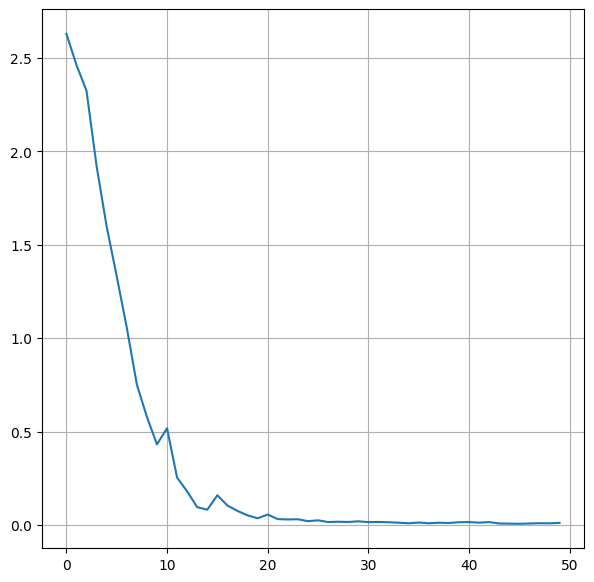

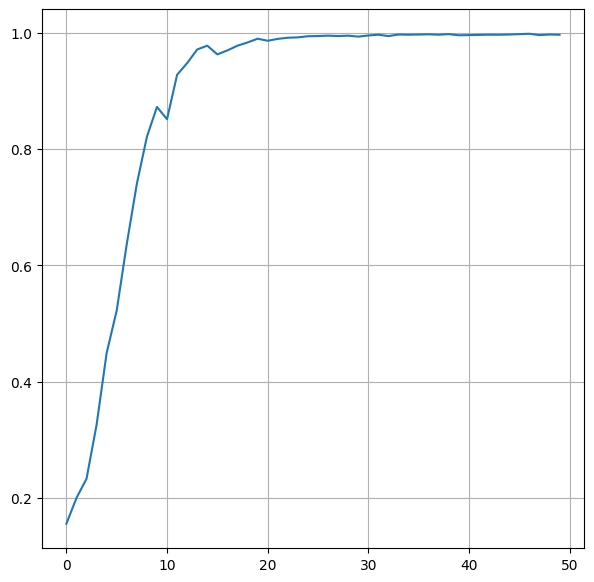

In [ ]:

plt.figure(figsize=(7,7))
plt.grid()
plt.plot(history.history['loss'])


plt.figure(figsize=(7,7))
plt.grid()
plt.plot(history.history['accuracy'])



In [ ]:

Xtest = Xtest.reshape(-1, windowSize, windowSize, K, 1)
Xtest.shape

(7175, 25, 25, 50, 1)

In [ ]:
ytest = to_categorical(ytest)
ytest.shape

(7175, 16)

In [ ]:

Y_pred_test = model.predict(Xtest)
y_pred_test = np.argmax(Y_pred_test, axis=1)

classification = classification_report(np.argmax(ytest, axis=1), y_pred_test)
print(classification)

225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        32
           1       1.00      0.99      1.00      1000
           2       1.00      1.00      1.00       581
           3       0.98      1.00      0.99       166
           4       1.00      0.98      0.99       338
           5       0.99      1.00      1.00       511
           6       0.95      1.00      0.98        20
           7       1.00      1.00      1.00       335
           8       1.00      1.00      1.00        14
           9       1.00      1.00      1.00       680
          10       1.00      1.00      1.00      1719
          11       1.00      1.00      1.00       415
          12       0.97      0.99      0.98       143
          13       1.00      1.00      1.00       886
          14       1.00      1.00      1.00       270
          15       0.98      1.00      0.99        65

    accuracy                          

In [ ]:
def AA_andEachClassAccuracy(confusion_matrix):
    counter = confusion_matrix.shape[0]
    list_diag = np.diag(confusion_matrix)
    list_raw_sum = np.sum(confusion_matrix, axis=1)
    each_acc = np.nan_to_num(truediv(list_diag, list_raw_sum))
    average_acc = np.mean(each_acc)
    return each_acc, average_acc

In [ ]:

def reports (X_test,y_test):
    #start = time.time()
    Y_pred = model.predict(X_test)
    y_pred = np.argmax(Y_pred, axis=1)
    #end = time.time()
    #print(end - start)

    target_names = ['Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn'
                        ,'Grass-pasture', 'Grass-trees', 'Grass-pasture-mowed',
                        'Hay-windrowed', 'Oats', 'Soybean-notill', 'Soybean-mintill',
                        'Soybean-clean', 'Wheat', 'Woods', 'Buildings-Grass-Trees-Drives','Stone-Steel-Towers']

    classification = classification_report(np.argmax(y_test, axis=1), y_pred, target_names=target_names)
    oa = accuracy_score(np.argmax(y_test, axis=1), y_pred)
    confusion = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
    each_acc, aa = AA_andEachClassAccuracy(confusion)
    kappa = cohen_kappa_score(np.argmax(y_test, axis=1), y_pred)
    score = model.evaluate(X_test, y_test, batch_size=32)
    Test_Loss =  score[0]*100
    Test_accuracy = score[1]*100
    print(f'Accuracy: {Test_accuracy}')
    #return classification, confusion, Test_Loss, Test_accuracy, oa*100, each_acc*100, aa*100, kappa*100

In [ ]:
reports(Xtest,ytest)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9974 - loss: 0.0095
Accuracy: 99.69338178634644


In [ ]:

def Patch(data,height_index,width_index):
    height_slice = slice(height_index, height_index+PATCH_SIZE)
    width_slice = slice(width_index, width_index+PATCH_SIZE)
    patch = data[height_slice, width_slice, :]

    return patch

In [ ]:
X, y = loadData()

In [ ]:

height = y.shape[0]
width = y.shape[1]
PATCH_SIZE = windowSize
numComponents = K

In [ ]:

X,pca = applyPCA(X, numComponents=numComponents)

In [ ]:

X = padWithZeros(X, PATCH_SIZE//2)

In [ ]:
# import numpy as np
# import cv2
# import matplotlib.pyplot as plt

# # Assuming your dataset is already loaded in X
# # For example, if you loaded an image via OpenCV:
# # X = cv2.imread('your_image.jpg')

# # Ensure that X is not None (image is loaded correctly)
# if X is None:
#     raise ValueError("Image not loaded correctly. Check your input data.")

# # Step 1: Get the height and width of the image
# height, width = X.shape[:2]
# print(f"Image loaded successfully with height: {height}, width: {width}")

# # Step 2: Initialize the output array
# outputs = np.zeros((height, width))

# # Step 3: Define the patch size (you can adjust this based on your model's input size)
# patch_size = (64, 64)  # Example patch size for segmentation or processing

# # Step 4: Loop over the image and process it in patches
# for i in range(0, height, patch_size[0]):
#     for j in range(0, width, patch_size[1]):
#         # Extract a patch from the image
#         image_patch = X[i:i+patch_size[0], j:j+patch_size[1]]

#         # Make sure we don't exceed the image bounds
#         if image_patch.shape[0] < patch_size[0] or image_patch.shape[1] < patch_size[1]:
#             continue  # Skip the patch if it's too small

#         # You can now apply your trained model on this patch
#         # Replace this with your actual model prediction, e.g., model.predict(image_patch)
#         # For now, simulate a prediction (binary classification example)
#         prediction = np.random.randint(0, 2, image_patch.shape[:2])  # Simulated binary prediction

#         # Place the prediction result in the output array
#         outputs[i:i+patch_size[0], j:j+patch_size[1]] = prediction

# # Step 5: Display the processed output image (visualizing the result)
# plt.imshow(outputs, cmap='gray')
# plt.title('Processed Output')
# plt.axis('off')  # Hide axis for better display
# plt.show()


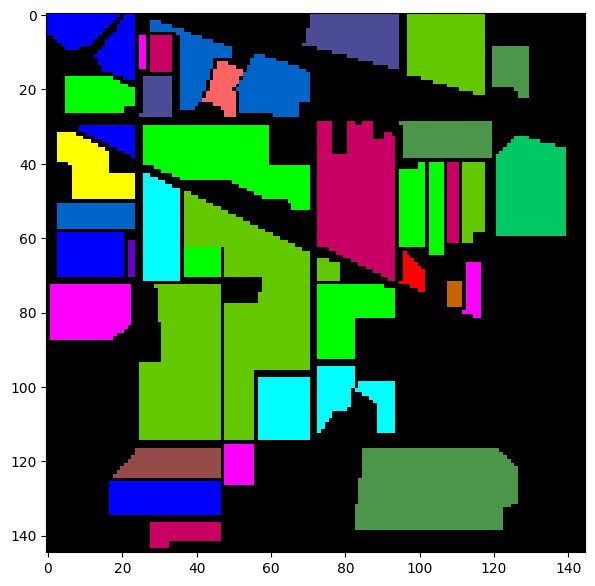

In [ ]:
ground_truth = spectral.imshow(classes = y,figsize =(7,7),cmap='jet')

In [ ]:
# predict_image = spectral.imshow(classes = outputs.astype(int),figsize =(7,7))

In [ ]:
# spectral.save_rgb("predictions.jpg", outputs.astype(int), colors=spectral.spy_colors)

In [ ]:



spectral.save_rgb(str("ind")+"_ground_truth.jpg", y, colors=spectral.spy_colors)